In [7]:
# ============================================================
# GENERAZIONE FBP: da tutti i sinogrammi alle ricostruzioni FBP
# ============================================================
# CPU only (FBP e' una formula diretta, non iterativa: e' comunque
# velocissima anche senza GPU).

from pathlib import Path
import numpy as np
import torch
from tqdm import tqdm
from utils.data_utils import load_normalized_image

from IPPy import operators

# ------------------------------------------------------------
# MODIFICA QUI: percorsi
# ------------------------------------------------------------
SINOGRAMS_DIR = Path("../sinograms")   # cartella con split/n_angoli/paziente/slice.npy
FBP_DIR = Path("../fbp")               # cartella di output, stessa struttura

SPLITS = ["train", "validation", "test"]
IMG_SIZE = (256, 256)

# Stessa identica definizione degli angoli usata per generare i sinogrammi
# (geometria "parallel", stesso trucco [1:-1] per 30/15) -- NON toccare.
ANGLE_CONFIGS_DEG = {
    90: np.linspace(-45, 45, 90),
    45: np.linspace(-45, 45, 45),
    30: np.linspace(-30, 30, 32)[1:-1],
    15: np.linspace(-30, 30, 17)[1:-1],
}

PROJECTORS = {
    n_angles: operators.CTProjector(
        img_shape=IMG_SIZE,
        angles=np.deg2rad(angles_deg),
        geometry="parallel",
        force_cpu=True,
    )
    for n_angles, angles_deg in ANGLE_CONFIGS_DEG.items()
}

failures = []
total_done = 0
total_skipped = 0

for split in SPLITS:
    print(f"\n=================== Split: {split.upper()} ===================")

    for n_angles, K in PROJECTORS.items():
        input_dir = SINOGRAMS_DIR / split / str(n_angles)
        output_dir = FBP_DIR / split / str(n_angles)

        if not input_dir.exists():
            print(f"  {split}/{n_angles}: cartella sorgente non trovata, salto.")
            continue

        sino_paths = sorted(input_dir.rglob("*.npy"))

        for sino_path in tqdm(sino_paths, desc=f"FBP [{split}-{n_angles} deg]"):
            rel_path = sino_path.relative_to(input_dir)
            out_path = (output_dir / rel_path).with_suffix(".npy")

            if out_path.exists():
                total_skipped += 1
                continue

            out_path.parent.mkdir(parents=True, exist_ok=True)

            try:
                sinogram = np.load(sino_path)
                y_delta = torch.from_numpy(sinogram).float().unsqueeze(0).unsqueeze(0)

                with torch.no_grad():
                    x_fbp = K.FBP(y_delta)

                x_fbp_np = x_fbp.squeeze().detach().numpy().astype(np.float32)
                np.save(out_path, x_fbp_np)
                total_done += 1

            except Exception as e:
                failures.append((str(sino_path), str(e)))
                continue

print(f"\nCompletato. Nuovi file: {total_done}, gia' presenti (saltati): {total_skipped}.")

if failures:
    print(f"\n{len(failures)} file falliti:")
    for path, err in failures[:20]:
        print(f"  - {path}: {err}")
    if len(failures) > 20:
        print(f"  ... e altre {len(failures) - 20}")

Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP

=================== Split: TRAIN ===================


FBP [train-15 deg]: 100%|██████████| 2733/2733 [00:01<00:00, 1770.16it/s]



=================== Split: VALIDATION ===================


FBP [validation-15 deg]: 100%|██████████| 573/573 [00:00<00:00, 2281.12it/s]



=================== Split: TEST ===================


FBP [test-15 deg]: 100%|██████████| 327/327 [00:00<00:00, 2002.61it/s]


Completato. Nuovi file: 0, gia' presenti (saltati): 14532.


In [8]:
# ============================================================
# VERIFICA: range di valori di FBP vs TV (per capire se serve un clip)
# ============================================================
import random

TV_DIR = Path("../tv_reconstructions")   # <-- aggiorna se il nome/percorso e' diverso in locale

all_fbp = list(FBP_DIR.rglob("*.npy"))
sample = random.sample(all_fbp, min(300, len(all_fbp)))

fbp_mins, fbp_maxs = [], []
tv_mins, tv_maxs = [], []

for fbp_path in sample:
    rel = fbp_path.relative_to(FBP_DIR)
    tv_path = TV_DIR / rel
    if not tv_path.exists():
        continue

    fbp_arr = np.load(fbp_path)
    tv_arr = np.load(tv_path)

    fbp_mins.append(fbp_arr.min()); fbp_maxs.append(fbp_arr.max())
    tv_mins.append(tv_arr.min()); tv_maxs.append(tv_arr.max())

fbp_mins, fbp_maxs = np.array(fbp_mins), np.array(fbp_maxs)
tv_mins, tv_maxs = np.array(tv_mins), np.array(tv_maxs)

print(f"Campione valutato: {len(fbp_mins)} coppie FBP/TV\n")

print("FBP -> min: media={:.4f} (peggiore={:.4f}), max: media={:.4f} (peggiore={:.4f})".format(
    fbp_mins.mean(), fbp_mins.min(), fbp_maxs.mean(), fbp_maxs.max()))
print("TV  -> min: media={:.4f} (peggiore={:.4f}), max: media={:.4f} (peggiore={:.4f})".format(
    tv_mins.mean(), tv_mins.min(), tv_maxs.mean(), tv_maxs.max()))

print(f"\nFBP sotto 0: {(fbp_mins < 0).sum()}/{len(sample)}   sopra 1: {(fbp_maxs > 1).sum()}/{len(sample)}")
print(f"TV  sotto 0: {(tv_mins < 0).sum()}/{len(sample)}   sopra 1: {(tv_maxs > 1).sum()}/{len(sample)}")

# quanto sono "gravi" gli sconfinamenti (non solo quanti, ma di quanto)
print(f"\nSconfinamento massimo FBP sotto 0: {fbp_mins.min():.4f}")
print(f"Sconfinamento massimo FBP sopra 1: {(fbp_maxs.max() - 1):.4f}")
print(f"Sconfinamento massimo TV sotto 0: {tv_mins.min():.4f}")
print(f"Sconfinamento massimo TV sopra 1: {(tv_maxs.max() - 1):.4f}")

Campione valutato: 300 coppie FBP/TV

FBP -> min: media=-0.6319 (peggiore=-1.2112), max: media=1.2253 (peggiore=1.9487)
TV  -> min: media=0.0000 (peggiore=0.0000), max: media=1.0967 (peggiore=1.7815)

FBP sotto 0: 300/300   sopra 1: 236/300
TV  sotto 0: 0/300   sopra 1: 221/300

Sconfinamento massimo FBP sotto 0: -1.2112
Sconfinamento massimo FBP sopra 1: 0.9487
Sconfinamento massimo TV sotto 0: 0.0000
Sconfinamento massimo TV sopra 1: 0.7815


In [9]:
frac_below_0, frac_above_1 = [], []
for fbp_path in sample:
    arr = np.load(fbp_path)
    frac_below_0.append((arr < 0).mean())
    frac_above_1.append((arr > 1).mean())

print(f"Frazione media di pixel sotto 0: {np.mean(frac_below_0)*100:.3f}%")
print(f"Frazione media di pixel sopra 1: {np.mean(frac_above_1)*100:.3f}%")

Frazione media di pixel sotto 0: 17.538%
Frazione media di pixel sopra 1: 0.216%


File FBP aperto: ..\fbp\train\90\C004\0.npy
Shape: (256, 256), min=-0.4982, max=1.1423
File TV aperto: ..\tv_reconstructions\train\90\C004\0.npy
Shape: (256, 256), min=0.0000, max=1.1829


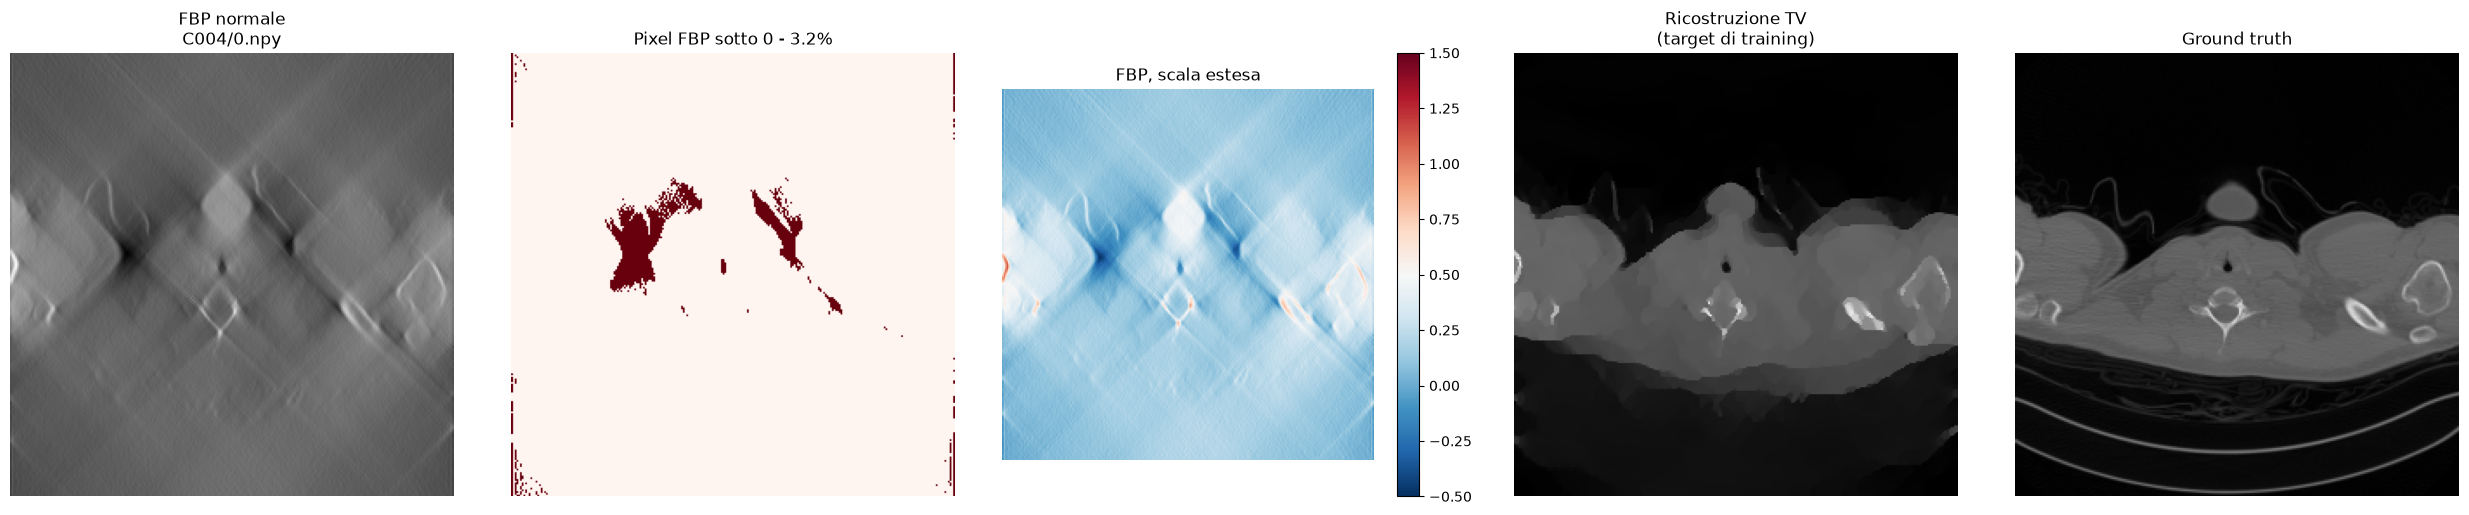

In [11]:
import matplotlib.pyplot as plt
from utils.data_utils import load_normalized_image

# Prende il primo paziente (ordine alfabetico) e la sua prima slice (0.npy)
# dentro train/90 -- non un campione casuale, proprio "il primo" letterale
train90_dir = FBP_DIR / "train" / "90"
first_patient_dir = sorted([p for p in train90_dir.iterdir() if p.is_dir()])[0]
fbp_path = first_patient_dir / "0.npy"

arr = np.load(fbp_path)
print(f"File FBP aperto: {fbp_path}")
print(f"Shape: {arr.shape}, min={arr.min():.4f}, max={arr.max():.4f}")

# Ricostruisce il path del ground truth e della ricostruzione TV corrispondenti
parts = fbp_path.relative_to(FBP_DIR).parts   # (split, n_angoli, paziente, "0.npy")
split, n_angoli, paziente, filename = parts
rel = Path(paziente) / filename

gt_dirname = {"train": "train_resized", "validation": "validation_resized", "test": "test_resized"}
gt_path = (Path("../dataset_resized") / gt_dirname[split] / rel).with_suffix(".png")
gt_arr = load_normalized_image(gt_path) if gt_path.exists() else None

TV_DIR = Path("../tv_reconstructions")   # <-- aggiorna se il nome/percorso e' diverso in locale
tv_path = TV_DIR / split / n_angoli / rel
tv_arr = np.load(tv_path) if tv_path.exists() else None
if tv_arr is not None:
    print(f"File TV aperto: {tv_path}")
    print(f"Shape: {tv_arr.shape}, min={tv_arr.min():.4f}, max={tv_arr.max():.4f}")
else:
    print(f"‼️ Non trovo la ricostruzione TV a: {tv_path}")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(arr, cmap="gray")
axes[0].set_title(f"FBP normale\n{paziente}/{filename}")
axes[0].axis("off")

axes[1].imshow(arr < 0, cmap="Reds")
axes[1].set_title(f"Pixel FBP sotto 0 - {(arr < 0).mean()*100:.1f}%")
axes[1].axis("off")

im = axes[2].imshow(arr, cmap="RdBu_r", vmin=-0.5, vmax=1.5)
axes[2].set_title("FBP, scala estesa")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2])

if tv_arr is not None:
    axes[3].imshow(tv_arr, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Ricostruzione TV\n(target di training)")
else:
    axes[3].text(0.5, 0.5, "TV non trovato", ha="center", va="center")
axes[3].axis("off")

if gt_arr is not None:
    axes[4].imshow(gt_arr, cmap="gray", vmin=0, vmax=1)
    axes[4].set_title("Ground truth")
else:
    axes[4].text(0.5, 0.5, "Ground truth\nnon trovato", ha="center", va="center")
axes[4].axis("off")

plt.tight_layout()
plt.show()